In [11]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import cv2

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])


height: 3688 
width: 5532


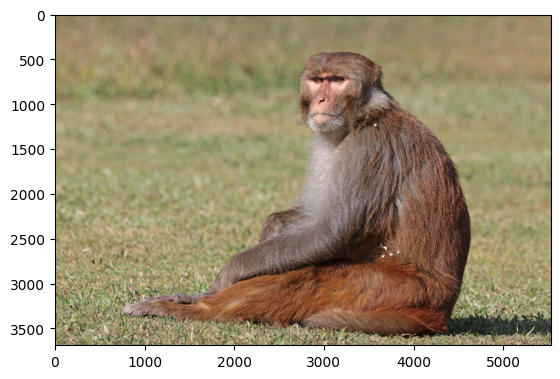

In [ ]:
img_path = f"{paths['livingstone_lab']}/Stimuli/temporal_context/images/macaque01.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, c = img.shape
print(f"height: {h} \nwidth: {w}")
plt.imshow(img)

In [88]:
h_stride, w_stride = 10, 10
h_win, w_win = 1200, 1800
h_st, w_st = 400, 2200


In [89]:
vid_path = f"{paths['livingstone_lab']}/Stimuli/temporal_context/videos/macaque01.mp4"

In [90]:
fps=50
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video = cv2.VideoWriter(vid_path, fourcc, fps, (w_win, h_win))

for i in np.arange(h_st, h - h_win - 1, h_stride)[::-1]:
    frame = img[i:i+h_win, w_st:w_st+w_win, :]
    
    frame_uint8 = (frame * 255).astype(np.uint8) if frame.max() <= 1 else frame
    frame_bgr = cv2.cvtColor(frame_uint8, cv2.COLOR_RGB2BGR)
    
    video.write(frame_bgr)

video.release()

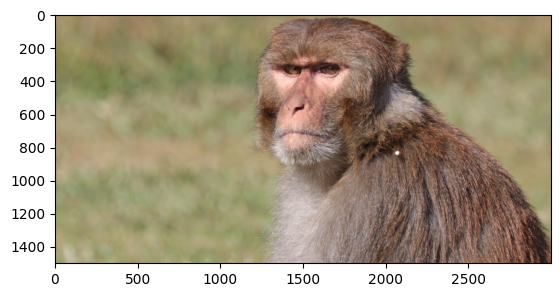

In [72]:
for i in np.arange(h_st, h - h_win -1, h_stride)[::-1]:
    plt.imshow(img[i:i+h_win,w_st:w_st+w_win,:])
    plt.show()
    clear_output(wait=True)


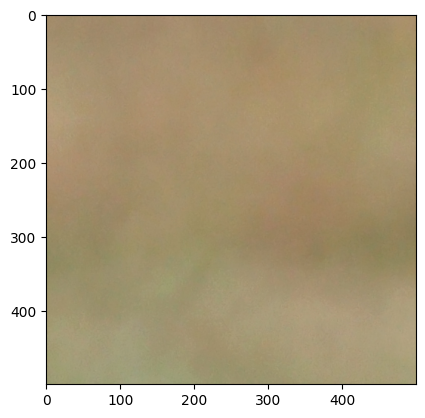

In [ ]:
for i in np.arange(w_st, w - w_win -1, w_stride):
    plt.imshow(img[h_st:h_st+h_win,i:i+w_win,:])
    plt.show()
    clear_output(wait=True)